# 00 Silver schema

What silver actually holds, checked before any modelling decision rests on it.

Pinned to the seven days 2026-09-14 through 2026-09-20. Silver gains a
partition every day and the write-up quotes these figures, so the window is
set as a constant in the next cell and every query inherits it.

Four questions:

1. How many days are there, and how much lands on each one.
2. Which event types exist, and which columns each one carries.
3. How often a session spans more than one day partition. Normalize writes
   one partition per day, so a session that crosses midnight has its events
   split across two files.
4. Whether censoring can be recovered. A session the attacker closed and a
   session the honeypot timed out have to be told apart. If they cannot be,
   the Kaplan-Meier curve is just the empirical distribution of durations
   and the survival analysis has nothing to say.

Nothing here writes to `/data`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from honeypot_analytics import db

# In memory. The workbench database file takes a single writer, and the
# scheduled jobs share the volume with this kernel.
con = db.connect()

# The window this notebook is pinned to. Silver keeps growing by a partition
# a day, but these numbers go into the write-up, so the window is a constant
# rather than whatever happens to be on the volume. 09-13 is left out: the
# honeypot started part way through it and that partition carries 1,339
# events against the 20-35k of a full day.
WINDOW_FROM = "2026-09-14"
WINDOW_TO = "2026-09-20"

# The read_parquet expression, with union_by_name and the hive types pinned,
# wrapped in the window so every query below inherits it. year, month and day
# are zero padded strings, which makes this a plain lexical comparison.
SILVER = (
    "(SELECT * FROM "
    + db.silver_events_source()
    + " WHERE year || '-' || month || '-' || day"
    + f" BETWEEN '{WINDOW_FROM}' AND '{WINDOW_TO}')"
)


def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## 1. Coverage

One row per day partition. A gap means either the honeypot was down or the
day was never normalized, and the two look the same from here.

In [2]:
coverage = q(f"""
    SELECT
        year || '-' || month || '-' || day AS day,
        count(*) AS events,
        count(DISTINCT session) AS sessions
    FROM {SILVER}
    GROUP BY 1
    ORDER BY 1
""")
coverage["day"] = pd.to_datetime(coverage["day"])
coverage

,day,events,sessions
0,2026-09-14,34564,4426
1,2026-09-15,18110,2342
2,2026-09-16,28986,3803
3,2026-09-17,30000,3864
4,2026-09-18,6175,810
5,2026-09-19,32689,4486
6,2026-09-20,20527,2781


In [3]:
span = pd.date_range(coverage["day"].min(), coverage["day"].max(), freq="D")
missing = span.difference(coverage["day"])

first = coverage["day"].min().date()
last = coverage["day"].max().date()
print(f"{len(coverage)} partitions, {first} to {last}")
print(f"{len(missing)} day(s) missing inside that range")
for day in missing:
    print("   ", day.date())

7 partitions, 2026-09-14 to 2026-09-20
0 day(s) missing inside that range


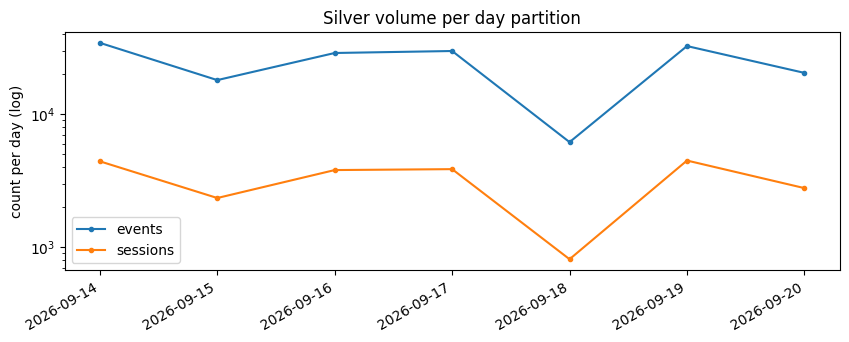

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(coverage["day"], coverage["events"], marker=".", label="events")
ax.plot(coverage["day"], coverage["sessions"], marker=".", label="sessions")
ax.set_yscale("log")
ax.set_ylabel("count per day (log)")
ax.set_title("Silver volume per day partition")
ax.legend()
fig.autofmt_xdate()
plt.show()

## 2. Event types

`days` is how many partitions an event type appears in at all. A type that
shows up on one day out of thirty is a different kind of rare from one that
shows up twice every day.

In [5]:
eventids = q(f"""
    SELECT
        eventid,
        count(*) AS events,
        count(DISTINCT session) AS sessions,
        count(DISTINCT year || month || day) AS days
    FROM {SILVER}
    GROUP BY 1
    ORDER BY events DESC
""")
eventids

,eventid,events,sessions,days
0,cowrie.session.connect,22511,22511,7
1,cowrie.session.closed,22511,22511,7
2,cowrie.client.version,21120,21120,7
3,cowrie.client.kex,20844,20844,7
4,cowrie.login.success,19679,19679,7
5,cowrie.command.input,17309,16963,7
6,cowrie.log.closed,17308,16963,7
7,cowrie.session.params,17308,16963,7
8,cowrie.direct-tcpip.request,4174,1904,7
9,cowrie.direct-tcpip.data,3843,1578,7


## 3. Columns by event type

Silver is the union of every column Cowrie emitted, so most columns are null
on most rows. What matters is which event type carries which column, because
that is what decides how the session table in 01 gets assembled.

In [6]:
schema = q(f"DESCRIBE SELECT * FROM {SILVER}")
print(f"{len(schema)} columns")
schema

53 columns


,column_name,column_type,null,key,default,extra
0,session,VARCHAR,YES,None,None,None
1,protocol,VARCHAR,YES,None,None,None
2,src_ip,VARCHAR,YES,None,None,None
3,src_port,BIGINT,YES,None,None,None
4,dst_ip,VARCHAR,YES,None,None,None
5,dst_port,BIGINT,YES,None,None,None
6,eventid,VARCHAR,YES,None,None,None
7,sensor,VARCHAR,YES,None,None,None
8,uuid,UUID,YES,None,None,None
9,timestamp,TIMESTAMP,YES,None,None,None


In [7]:
# count(col) skips nulls, so one grouped query gives the fill rate of every
# column for every event type. The column list is only known at runtime,
# hence the generated SQL.
grouping = ("eventid", "year", "month", "day")
value_columns = [c for c in schema["column_name"] if c not in grouping]
counts = ", ".join(f'count("{c}") AS "{c}"' for c in value_columns)

fill = q(f"""
    SELECT eventid, count(*) AS events, {counts}
    FROM {SILVER}
    GROUP BY 1
    ORDER BY events DESC
""").set_index("eventid")

fill_ratio = fill[value_columns].div(fill["events"], axis=0)
fill_ratio.round(3)

,session,protocol,src_ip,src_port,dst_ip,dst_port,sensor,uuid,timestamp,message,version,hassh,hasshAlgorithms,kexAlgs,keyAlgs,encCS,macCS,compCS,langCS,duration_ms,username,password,arch,input,ttylog,size,shasum,duplicate,fingerprint,key,type,width,height,orig_ip,orig_port,data,id,outfile,destfile,source_file,ja4h,ja4,filename,messagenum,datalen,realm,name,value,url
eventid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
cowrie.session.connect,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cowrie.session.closed,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cowrie.client.version,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cowrie.client.kex,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cowrie.login.success,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cowrie.command.input,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,1.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cowrie.session.params,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cowrie.log.closed,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000,0.0,0.0,1.0,1.0,1.0,1.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cowrie.direct-tcpip.request,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
for eventid, row in fill_ratio.iterrows():
    carried = row[row > 0].sort_values(ascending=False)
    events = int(fill.loc[eventid, "events"])
    print(f"{eventid}  ({events} events)")
    if carried.empty:
        print("    nothing beyond the columns every event has")
    for column, ratio in carried.items():
        print(f"    {column:<28} {ratio:6.1%}")
    print()

cowrie.session.connect  (22511 events)
    session                      100.0%
    protocol                     100.0%
    src_ip                       100.0%
    src_port                     100.0%
    dst_ip                       100.0%
    dst_port                     100.0%
    sensor                       100.0%
    uuid                         100.0%
    timestamp                    100.0%
    message                      100.0%
    source_file                  100.0%

cowrie.session.closed  (22511 events)
    session                      100.0%
    protocol                     100.0%
    src_ip                       100.0%
    src_port                     100.0%
    dst_ip                       100.0%
    dst_port                     100.0%
    sensor                       100.0%
    uuid                         100.0%
    timestamp                    100.0%
    message                      100.0%
    duration_ms                  100.0%
    source_file                  100.0%

c

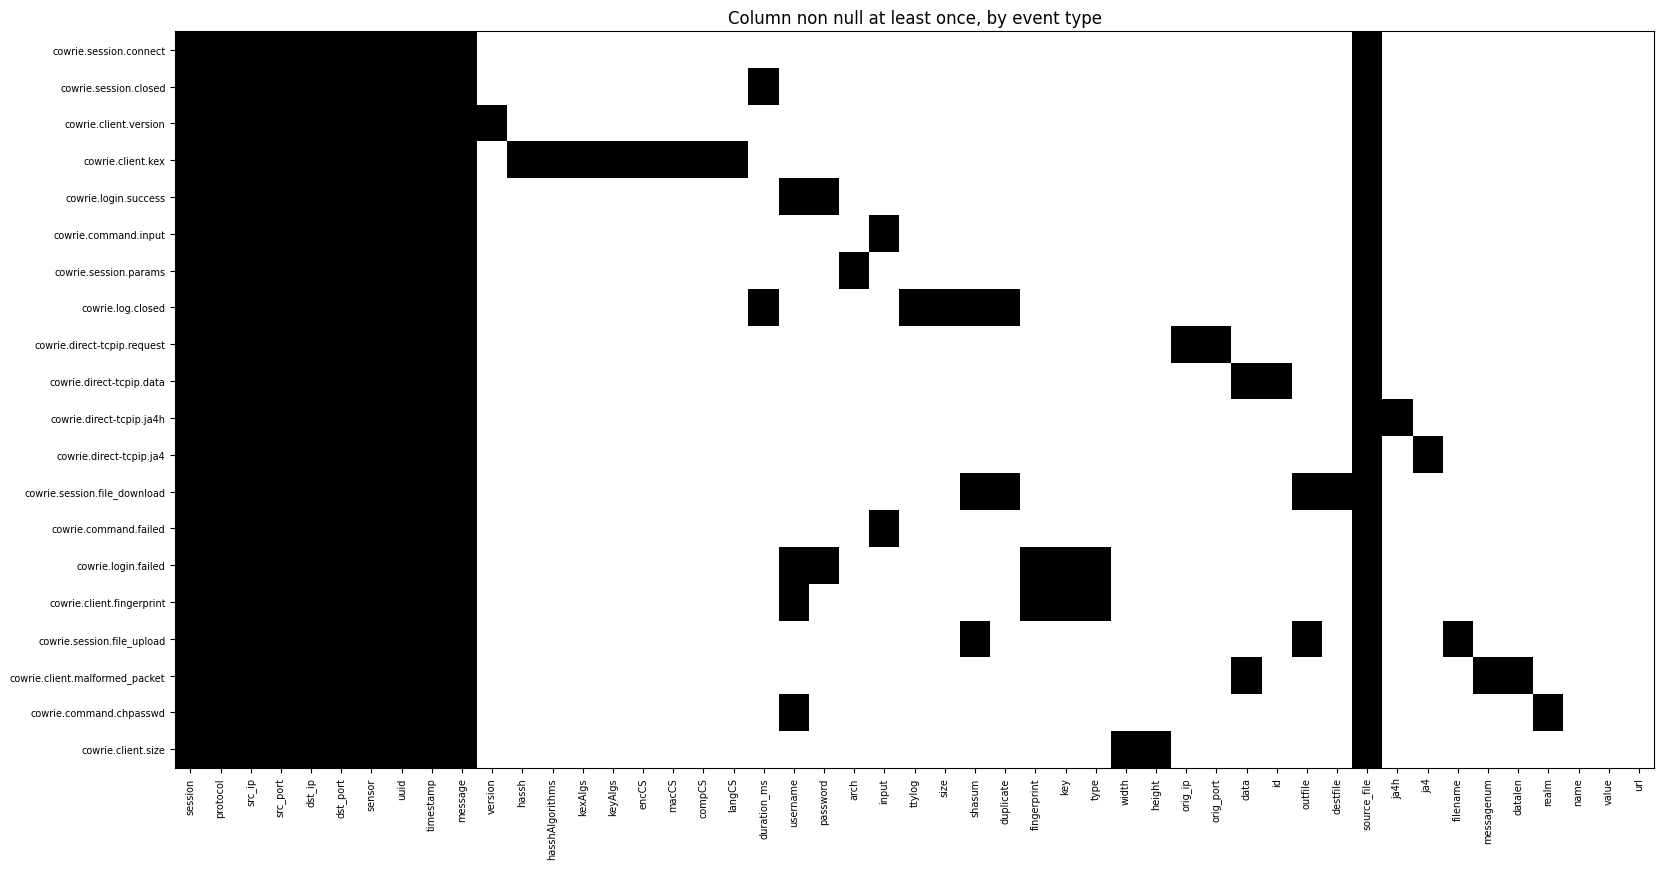

In [9]:
present = (fill_ratio > 0).astype(int)

fig, ax = plt.subplots(
    figsize=(0.26 * len(present.columns) + 4, 0.34 * len(present) + 2)
)
ax.imshow(present.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_xticks(range(len(present.columns)))
ax.set_xticklabels(present.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(present.index)))
ax.set_yticklabels(present.index, fontsize=7)
ax.set_title("Column non null at least once, by event type")
fig.tight_layout()
plt.show()

The fields 01 is going to reach for, checked by name. Anything other than
`ok` here changes what the session table can hold.

In [10]:
expected = {
    "cowrie.session.connect": ["src_ip"],
    "cowrie.session.closed": ["duration"],
    "cowrie.login.success": ["username", "password"],
    "cowrie.login.failed": ["username", "password"],
    "cowrie.command.input": ["input"],
    "cowrie.client.version": ["version"],
}

rows = []
for eventid, columns in expected.items():
    for column in columns:
        ratio = np.nan
        if eventid not in fill_ratio.index:
            state = "event type absent"
        elif column not in fill_ratio.columns:
            state = "column absent"
        else:
            ratio = fill_ratio.loc[eventid, column]
            state = "ok" if ratio > 0 else "always null"
        rows.append(
            {"eventid": eventid, "column": column, "fill": ratio, "state": state}
        )

pd.DataFrame(rows)

,eventid,column,fill,state
0,cowrie.session.connect,src_ip,1.000000,ok
1,cowrie.session.closed,duration,NaN,column absent
2,cowrie.login.success,username,1.000000,ok
3,cowrie.login.success,password,1.000000,ok
4,cowrie.login.failed,username,1.000000,ok
5,cowrie.login.failed,password,0.841121,ok
6,cowrie.command.input,input,1.000000,ok
7,cowrie.client.version,version,1.000000,ok


In [11]:
# client.kex is listed as a feature in the plan but its field names are not
# assumed here, so print whatever it carries.
kex = "cowrie.client.kex"
if kex in fill_ratio.index:
    carried = fill_ratio.loc[kex]
    print(carried[carried > 0].sort_values(ascending=False).round(3))
else:
    print(f"{kex} is not in silver")

session            1.0
protocol           1.0
src_ip             1.0
src_port           1.0
dst_ip             1.0
dst_port           1.0
sensor             1.0
uuid               1.0
timestamp          1.0
message            1.0
hassh              1.0
hasshAlgorithms    1.0
kexAlgs            1.0
keyAlgs            1.0
encCS              1.0
macCS              1.0
compCS             1.0
langCS             1.0
source_file        1.0
Name: cowrie.client.kex, dtype: float64


## 4. Sessions across day partitions

A session that opens before midnight and closes after it has its connect in
one parquet file and its closed in the next. Reading the whole glob puts them
back together, so this only matters if some later step ever works one day at
a time.

In [12]:
spanning = q(f"""
    WITH per_session AS (
        SELECT
            session,
            count(DISTINCT year || month || day) AS partitions,
            count(*) AS events
        FROM {SILVER}
        WHERE session IS NOT NULL
        GROUP BY 1
    )
    SELECT partitions, count(*) AS sessions, sum(events) AS total_events
    FROM per_session
    GROUP BY 1
    ORDER BY 1
""")
spanning

,partitions,sessions,total_events
0,1,22510,171043.0
1,2,1,8.0


The same session id appearing in two partitions has two possible causes, and
the elapsed time separates them. A span of minutes or hours is a real
midnight crossing. A span of days means Cowrie reused the id, and then the id
alone is not a key and 01 has to group on something more.

In [13]:
crossers = q(f"""
    WITH per_session AS (
        SELECT
            session,
            count(DISTINCT year || month || day) AS partitions,
            count(*) AS events,
            min(CAST("timestamp" AS TIMESTAMP)) AS first_seen,
            max(CAST("timestamp" AS TIMESTAMP)) AS last_seen
        FROM {SILVER}
        WHERE session IS NOT NULL
        GROUP BY 1
    )
    SELECT *, date_diff('second', first_seen, last_seen) AS span_sec
    FROM per_session
    WHERE partitions > 1
    ORDER BY span_sec DESC
""")
print(f"{len(crossers)} session(s) land in more than one partition")
crossers.head(30)

1 session(s) land in more than one partition


,session,partitions,events,first_seen,last_seen,span_sec
0,3bfb11230f49,2,8,2026-09-18 23:59:34.058329,2026-09-19 00:00:23.018181,49


## 5. Session skeleton

01 builds one row per session out of a connect and a closed. This is the
check that the pair is actually there.

In [14]:
skeleton = q(f"""
    WITH per_session AS (
        SELECT
            session,
            count(*) FILTER (WHERE eventid = 'cowrie.session.connect') AS connects,
            count(*) FILTER (WHERE eventid = 'cowrie.session.closed') AS closes
        FROM {SILVER}
        WHERE session IS NOT NULL
        GROUP BY 1
    )
    SELECT connects, closes, count(*) AS sessions
    FROM per_session
    GROUP BY 1, 2
    ORDER BY sessions DESC
""")
skeleton

,connects,closes,sessions
0,1,1,22511


In [15]:
# How much happens inside a session at all. Most of these will be a connect,
# a couple of login attempts and a closed.
per_session_events = q(f"""
    WITH per_session AS (
        SELECT session, count(*) AS events
        FROM {SILVER}
        WHERE session IS NOT NULL
        GROUP BY 1
    )
    SELECT events, count(*) AS sessions
    FROM per_session
    GROUP BY 1
    ORDER BY events
""")
per_session_events.head(25)

,events,sessions
0,2,1391
1,3,276
2,4,1070
3,5,895
4,6,331
5,7,39
6,8,16960
7,9,2
8,10,14
9,11,781


## 6. Censoring

The event of interest is the attacker hanging up. A session the honeypot cut
off (idle timeout, or whatever else Cowrie enforces) is censored: it would
have run longer had nobody interfered.

Two ways to tell them apart, in order of preference. Either `session.closed`
records a reason, or it does not and the timeout has to be read off the
duration distribution as a spike sitting on one value. If neither works, the
definition of `event_observed` needs rethinking before 03.

In [16]:
closed = "cowrie.session.closed"
carried = fill_ratio.loc[closed]
carried[carried > 0].sort_values(ascending=False).round(3)

session        1.0
protocol       1.0
src_ip         1.0
src_port       1.0
dst_ip         1.0
dst_port       1.0
sensor         1.0
uuid           1.0
timestamp      1.0
message        1.0
duration_ms    1.0
source_file    1.0
Name: cowrie.session.closed, dtype: float64

In [17]:
q(f"""
    SELECT message, count(*) AS events
    FROM {SILVER}
    WHERE eventid = 'cowrie.session.closed'
    GROUP BY 1
    ORDER BY events DESC
    LIMIT 50
""")

,message,events
0,Connection lost after 1 milliseconds,383
1,Connection lost after 0 milliseconds,186
2,Connection lost after 120002 milliseconds,113
3,Connection lost after 120003 milliseconds,72
4,Connection lost after 120004 milliseconds,53
5,Connection lost after 120005 milliseconds,48
6,Connection lost after 2 milliseconds,44
7,Connection lost after 120006 milliseconds,38
8,Connection lost after 3 milliseconds,34
9,Connection lost after 4 milliseconds,31


In [18]:
durations = q(f"""
    SELECT session, duration_ms
    FROM {SILVER}
    WHERE eventid = 'cowrie.session.closed' AND duration_ms IS NOT NULL
""")
durations["duration_ms"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count     22511.000000
mean       7976.447781
std       22231.991559
min           0.000000
50%        2056.000000
90%       11992.000000
95%       38652.000000
99%      120008.000000
max      378502.000000
Name: duration_ms, dtype: float64

In [19]:
# A timeout is a constant, so it survives rounding to the second and rises to
# the top here. Organic hang-ups spread out and do not.
q(f"""
    SELECT round(duration_ms) AS duration_sec, count(*) AS sessions
    FROM {SILVER}
    WHERE eventid = 'cowrie.session.closed' AND duration_ms IS NOT NULL
    GROUP BY 1
    ORDER BY sessions DESC
    LIMIT 25
""")

,duration_sec,sessions
0,1,383
1,0,186
2,120002,113
3,120003,72
4,120004,53
5,120005,48
6,2,44
7,120006,38
8,3,34
9,4,31


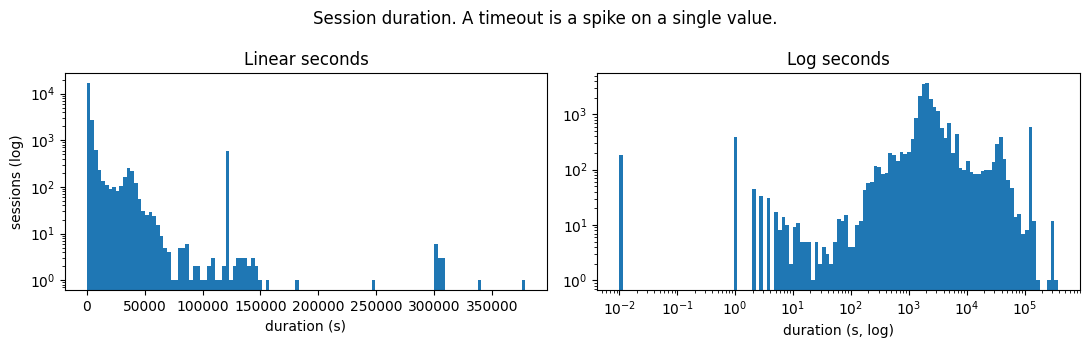

In [20]:
positive = durations["duration_ms"].clip(lower=0.01)
log_bins = np.logspace(np.log10(positive.min()), np.log10(positive.max()), 120)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(durations["duration_ms"], bins=120)
axes[0].set_yscale("log")
axes[0].set_xlabel("duration (s)")
axes[0].set_ylabel("sessions (log)")
axes[0].set_title("Linear seconds")

axes[1].hist(positive, bins=log_bins)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("duration (s, log)")
axes[1].set_title("Log seconds")

fig.suptitle("Session duration. A timeout is a spike on a single value.")
fig.tight_layout()
plt.show()